# E-commerce Sales Analysis

**Objective:** Analyze transactions to identify revenue drivers, seasonal patterns, and high-value customer segments.

**Dataset:** UCI Online Retail II (2009-2011)  
**Author:** Hamdi Ahmed
**Date:** 26/06/2026

## 1. Setup and Data Loading

In [1]:
import duckdb
import pandas as pd

cleaned = pd.read_csv('../data/processed/cleaned.csv')
registered = pd.read_csv('../data/processed/registered_only.csv')

from IPython.display import HTML, display


display(HTML("""
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js"></script>
<script>window._chartjsLoaded = true;</script>
"""))


print(f"Loaded {len(cleaned):,} rows for cleaned data")
print(f"Loaded {len(registered):,} rows for cleaned data with registered customers only")
pd.set_option('display.float_format', '{:,.2f}'.format)

Loaded 1,003,430 rows for cleaned data
Loaded 776,592 rows for cleaned data with registered customers only


In [2]:
con = duckdb.connect()
con.register('registered', registered)

print("Columns:", list(registered.columns))

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'is_guest', 'Revenue', 'Year', 'Month', 'DayOfWeek', 'Hour', 'IsWeekend', 'WeekStart', 'MonthStart']


## 2. Revenue Analysis

In [5]:
# Monthly total revenue, orders and customers

con.execute("""
    SELECT
        strftime(CAST(InvoiceDate AS DATE), '%b-%Y') AS month_year,
        SUM(Revenue) as total_revenue,
        COUNT(DISTINCT Invoice) orders,
        COUNT(DISTINCT CustomerID) as customers
    FROM cleaned
    GROUP BY strftime(CAST(InvoiceDate AS DATE), '%b-%Y')
    ORDER BY strftime(CAST(InvoiceDate AS DATE), '%b-%Y')
""").fetchdf()

,month_year,total_revenue,orders,customers
0,Apr-2010,"646,474.06",1436,939
1,Apr-2011,"515,469.66",1235,853
2,Aug-2010,"674,192.89",1402,910
3,Aug-2011,"724,308.16",1339,933
4,Dec-2009,"798,232.03",1671,952
5,Dec-2010,"775,714.95",1550,884
6,Dec-2011,"614,499.25",816,614
7,Feb-2010,"537,926.69",1189,771
8,Feb-2011,"507,866.54",1093,757
9,Jan-2010,"612,455.50",1053,702


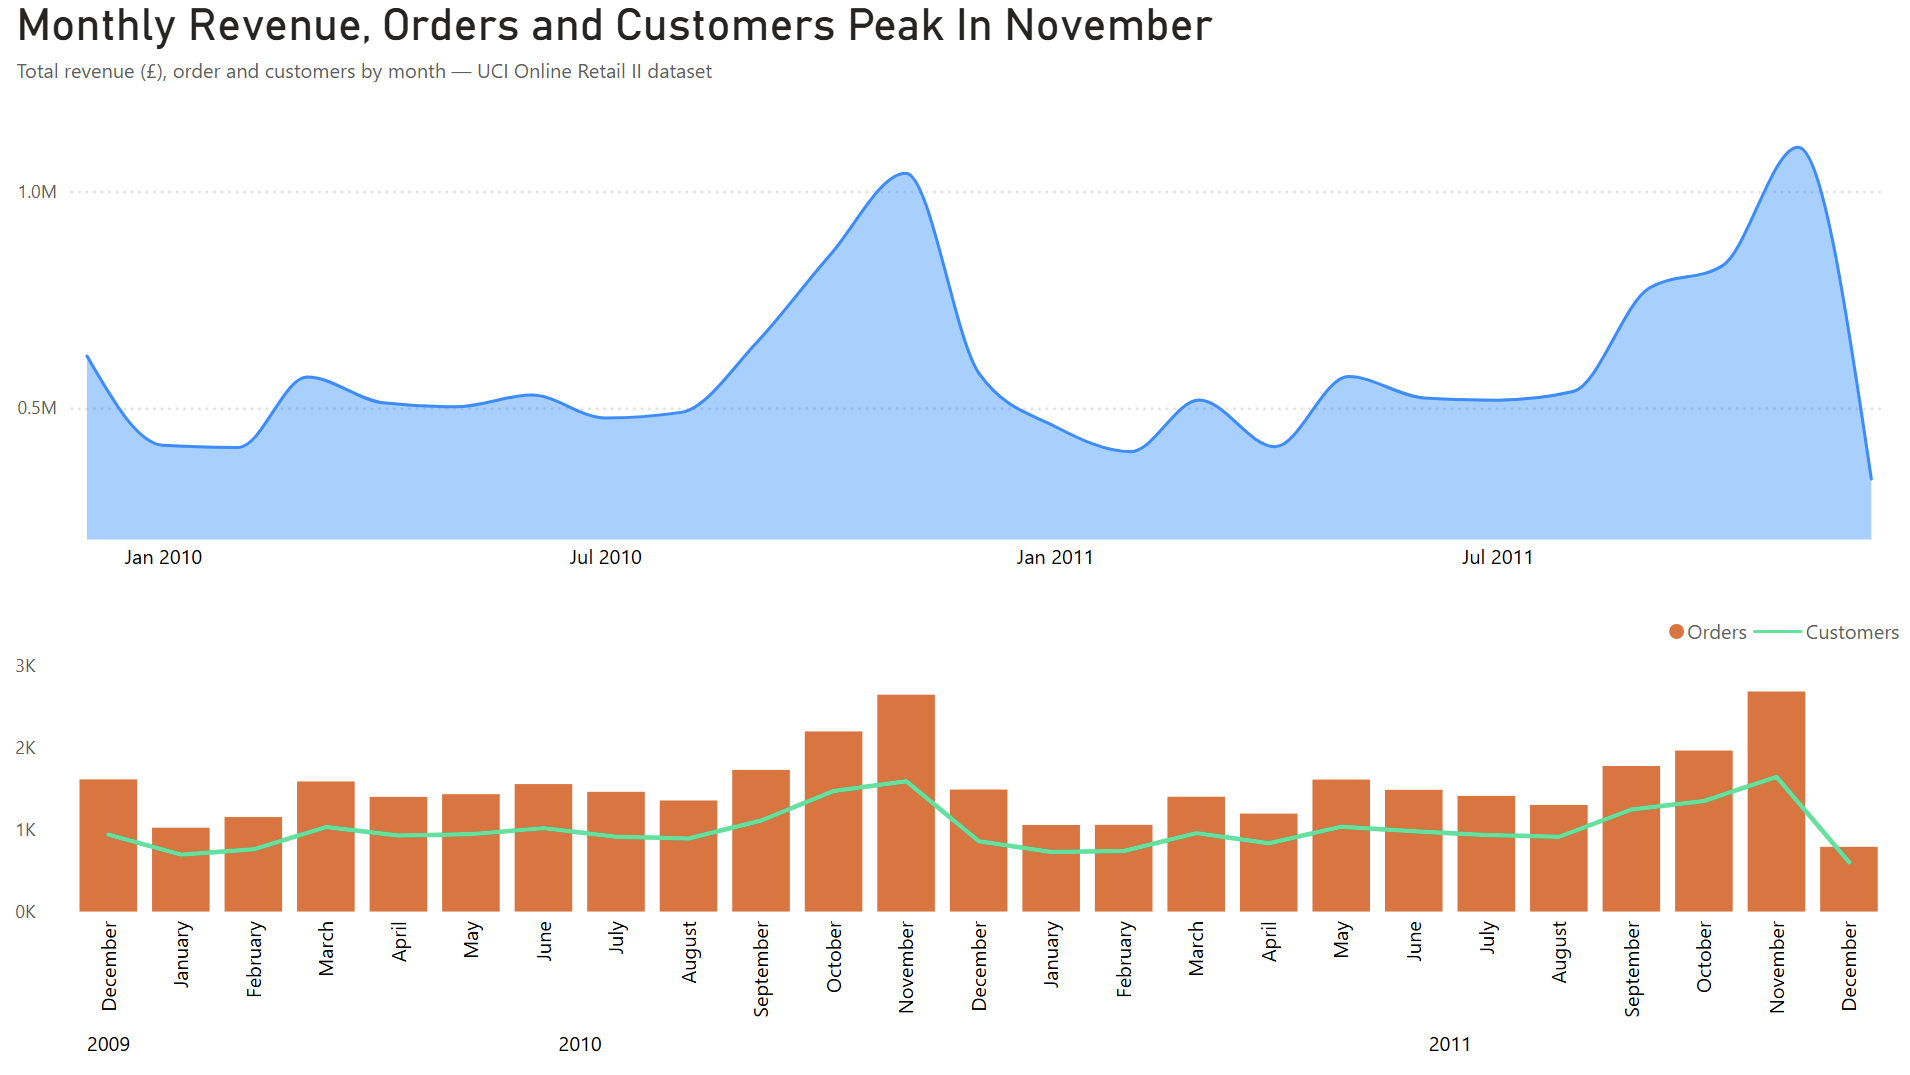

In [6]:
from IPython.display import Image
Image('../docs/img/monthly_rev_orders_cust.png', width=1000, height=600)

In [7]:
con.execute("""
    WITH monthly_totals AS (
        SELECT
            strftime(CAST(InvoiceDate AS DATE), '%B') AS month_name,
            SUM(Revenue) AS total_revenue,
            COUNT(DISTINCT Invoice) AS orders,
            COUNT(DISTINCT CustomerID) AS customers
        FROM cleaned
        GROUP BY 
            strftime(CAST(InvoiceDate AS DATE), '%B')
    )
    SELECT
        month_name as "Month",
        ROUND(AVG(total_revenue), 2)  AS "Average Revenue",
        ROUND(AVG(orders), 2) AS "Average Number of Orders",
        ROUND(AVG(customers), 2) AS "Average Number of Customers"
    FROM monthly_totals
    GROUP BY month_name
    ORDER BY AVG(total_revenue) DESC
""").fetchdf()

,Month,Average Revenue,Average Number of Orders,Average Number of Customers
0,November,"2,881,867.82","5,470.00","2,579.00"
1,October,"2,197,894.55","4,249.00","2,361.00"
2,December,"2,188,446.23","4,037.00","1,810.00"
3,September,"1,897,622.54","3,607.00","1,968.00"
4,March,"1,451,590.37","3,087.00","1,682.00"
5,June,"1,435,066.31","3,140.00","1,686.00"
6,August,"1,398,501.05","2,741.00","1,510.00"
7,May,"1,383,621.97","3,152.00","1,672.00"
8,July,"1,321,332.09","2,959.00","1,553.00"
9,January,"1,282,894.96","2,134.00","1,195.00"


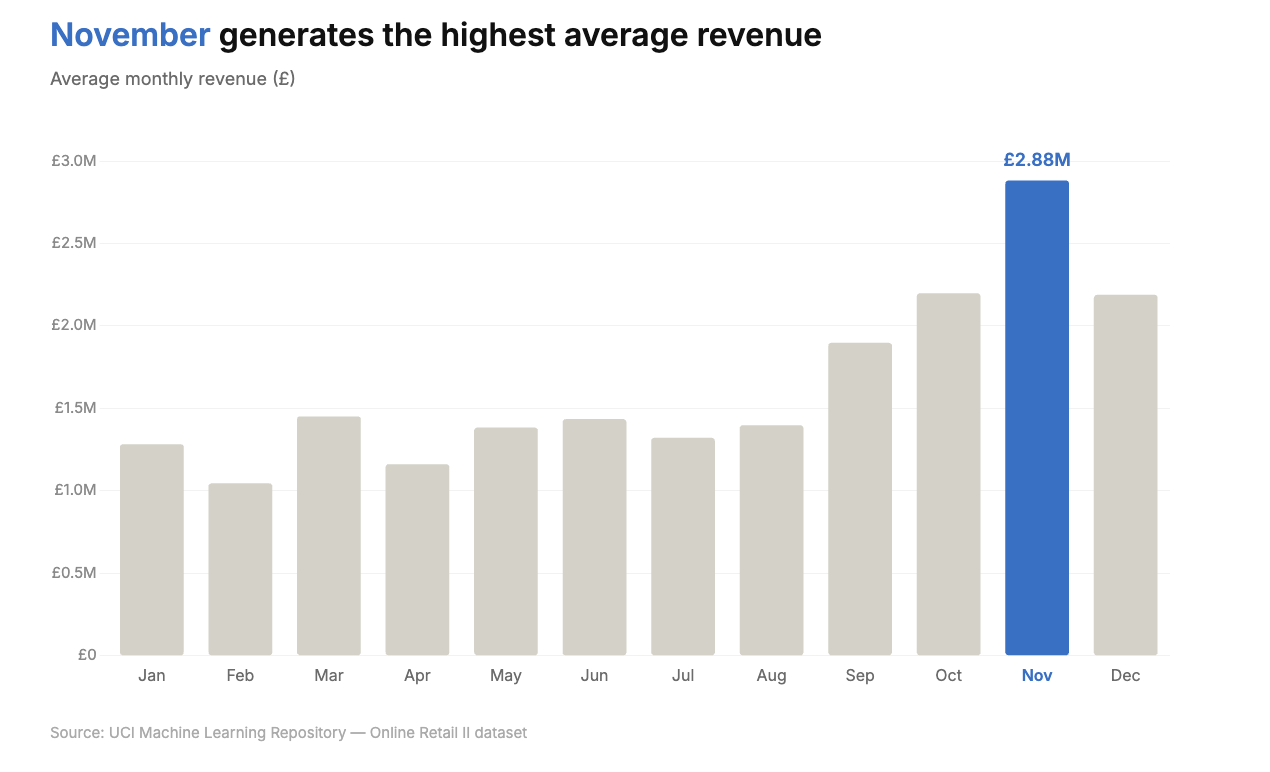

In [11]:
from IPython.display import Image
Image('../docs/img/average_monthly_revenue_chart.png')

In [12]:
totals = con.execute("""
    SELECT
        SUM(Revenue) as total_revenue,
        COUNT(DISTINCT Invoice) AS total_orders,
        COUNT(DISTINCT CustomerID) AS total_customers
    FROM
        cleaned
""").fetchdf()

totals

,total_revenue,total_orders,total_customers
0,"19,646,574.84",39529,5852


## 4. Customer Segmentation 

In [13]:
# Recency = Number of days since last purchase

# Frequency = Number of purchases made

# Monetary = Total amount spent


rfm_raw = con.execute("""
    SELECT
        CustomerID,
        DATE_DIFF('day',
            MAX(CAST(InvoiceDate AS DATE)),
            (SELECT MAX(CAST(InvoiceDate AS DATE)) + INTERVAL '1 day' FROM registered)
        ) AS Recency,
        COUNT(DISTINCT Invoice) AS Frequency,
        SUM(Revenue) AS Monetary
    FROM registered
    GROUP BY CustomerID
""").fetchdf()

rfm_raw

,CustomerID,Recency,Frequency,Monetary
0,"16,891.00",2,11,"1,727.94"
1,"16,225.00",45,15,"2,859.31"
2,"14,911.00",2,373,"272,252.79"
3,"18,109.00",2,38,"9,555.71"
4,"13,713.00",409,3,740.76
...,...,...,...,...
5847,"17,831.00",34,1,35.40
5848,"18,113.00",369,1,76.32
5849,"15,999.00",736,1,20.40
5850,"16,165.00",506,1,79.90


In [14]:
rfm_columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

query_parts = []

for column in rfm_columns:
    piece = f"""
    SELECT 
        '{column}' as column_name,
        COUNT(*) as total,
        MIN({column}) as min,
        QUANTILE_CONT({column},0.25) as qntile_25,
        QUANTILE_CONT({column},0.5) as median,
        QUANTILE_CONT({column},0.75) as qntile_75,
        MAX({column}) as max,
        ROUND(AVG({column}),2) as mean  
    FROM 
        rfm_raw
    """
    query_parts.append(piece)
rfm_distribution_query = " UNION ALL ".join(query_parts)

In [15]:
rfm_distribution_df = con.execute(rfm_distribution_query).fetchdf()
rfm_distribution_df

,column_name,total,min,qntile_25,median,qntile_75,max,mean
0,CustomerID,5852,"12,346.00","13,837.75","15,320.50","16,802.25","18,287.00","15,319.71"
1,Recency,5852,1.00,26.00,96.00,380.00,739.00,200.73
2,Frequency,5852,1.00,1.00,3.00,7.00,373.00,6.26
3,Monetary,5852,2.95,339.57,856.02,"2,241.03","580,987.04","2,916.87"


In [16]:
rfm_segments = con.execute("""
    WITH rfm_scored AS (
        SELECT *,
            NTILE(5) OVER (ORDER BY Recency  DESC) AS R_Score,
            NTILE(5) OVER (ORDER BY Frequency ASC) AS F_Score,
            NTILE(5) OVER (ORDER BY Monetary  ASC) AS M_Score
        FROM rfm_raw
    )
    SELECT *,
        CAST(R_Score AS VARCHAR) || 
        CAST(F_Score AS VARCHAR) || 
        CAST(M_Score AS VARCHAR) AS RFM_Score,
        CASE
            WHEN R_Score >= 4 AND F_Score >= 4 AND M_Score >= 4 THEN 'Champions'
            WHEN R_Score >= 3 AND F_Score >= 3 AND M_Score >= 3 THEN 'Loyal'
            WHEN R_Score >= 4 AND F_Score <= 2 THEN 'New Customers'
            WHEN R_Score >= 3 AND F_Score <= 2 THEN 'Promising'
            WHEN R_Score <= 2 AND F_Score >= 3 AND M_Score >= 3 THEN 'At Risk'
            WHEN R_Score <= 2 AND F_Score <= 2 THEN 'Lost'
            ELSE 'Needs Attention'
        END AS Segment
    FROM rfm_scored
""").fetchdf()
rfm_segments

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,"14,095.00",723,1,2.95,1,1,1,111,Lost
1,"16,738.00",298,1,3.75,2,1,1,211,Lost
2,"13,788.00",506,1,3.75,1,1,1,111,Lost
3,"14,792.00",64,1,6.20,3,2,1,321,Promising
4,"15,913.00",535,1,6.30,1,1,1,111,Lost
...,...,...,...,...,...,...,...,...,...
5847,"17,450.00",9,51,"244,784.25",5,5,5,555,Champions
5848,"14,911.00",2,373,"272,252.79",5,5,5,555,Champions
5849,"14,156.00",10,144,"303,069.88",5,5,5,555,Champions
5850,"14,646.00",2,145,"526,751.52",5,5,5,555,Champions


In [17]:
con.execute("""
    SELECT
        Segment,
        COUNT(*) AS Customers,
        ROUND(SUM(Monetary), 2) AS Total_Revenue,
        ROUND(AVG(Monetary), 2) AS Avg_Revenue
    FROM 
        rfm_segments
    GROUP BY 
        Segment
    ORDER BY 
        Total_Revenue DESC
""").fetchdf()

,Segment,Customers,Total_Revenue,Avg_Revenue
0,Champions,1277,"11,606,767.99","9,089.09"
1,Loyal,1178,"2,581,889.95","2,191.76"
2,At Risk,609,"1,503,818.11","2,469.32"
3,Lost,1563,"646,405.30",413.57
4,New Customers,451,"388,487.66",861.39
5,Needs Attention,446,"181,809.65",407.64
6,Promising,328,"160,361.11",488.91


In [18]:
from IPython.display import IFrame

# Load Chart.js from local file
with open('../chart.umd.js', 'r') as f:
    chartjs = f.read()

# Run query and save result
rfm_summary = con.execute("""
    SELECT
        Segment,
        COUNT(*) AS Customers,
        ROUND(SUM(Monetary), 2) AS Total_Revenue,
        ROUND(AVG(Monetary), 2) AS Avg_Revenue
    FROM rfm_segments
    GROUP BY Segment
    ORDER BY Total_Revenue DESC
""").fetchdf()

# Extract values from DataFrame
segments   = rfm_summary['Segment'].tolist()
customers  = rfm_summary['Customers'].tolist()
revenue    = rfm_summary['Total_Revenue'].tolist()
total_rev  = sum(revenue)
total_cust = sum(customers)

# Dynamic insight numbers
top_seg      = segments[0]
top_cust_pct = round(customers[0] / total_cust * 100)
top_rev_pct  = round(revenue[0] / total_rev * 100)

# Assign colours by segment name so order does not matter
colour_map = {
    'Champions':'#534AB7',
    'Loyal': '#0F6E56',
    'At Risk': '#D85A30',
    'Lost': '#888780',
    'Needs Attention': '#CC79A7',
    'New Customers': '#BA7517',
    'Promising': '#E69F00'  
}
seg_colours = [colour_map.get(s, '#888780') for s in segments]
bar_colours = ['#534AB7' if i == 0 else '#C8C5BB' for i in range(len(segments))]

# Build HTML
html_content = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500&display=swap" rel="stylesheet">
<style>
body{{margin:0;padding:0}}
.rfm-wrap{{font-family:'Inter',sans-serif;padding:1.5rem 2rem;background:#fff;color:#18160F}}
.rfm-title{{font-size:22px;font-weight:500;color:#18160F;margin:0 0 4px;line-height:1.4}}
.rfm-sub{{font-size:15px;color:#6A6158;margin:0 0 20px}}
.rfm-grid{{display:grid;grid-template-columns:1fr 1fr;gap:40px}}
.rfm-clabel{{font-size:15px;color:#6A6158;margin:0 0 10px}}
.rfm-legend{{display:flex;gap:8px;flex-wrap:wrap;margin-top:12px}}
.rfm-legend span{{font-size:16px;color:#6A6158;display:flex;align-items:center;gap:4px}}
.rfm-legend i{{width:9px;height:9px;border-radius:2px;display:inline-block;flex-shrink:0}}
.rfm-source{{font-size:13px;color:#ABA49B;margin:16px 0 0}}
</style>
</head>
<body>
<div class="rfm-wrap">
  <p class="rfm-title">
    <span style="color:#534AB7;">{top_seg}</span> make up {top_cust_pct}% of customers
    but generate {top_rev_pct}% of total revenue
  </p>

  <br>

  <div class="rfm-grid">
    <div>
      <p class="rfm-clabel">Share of customers by segment</p>
      <div style="position:relative;width:100%;height:280px;">
        <canvas id="custChart"></canvas>
      </div>
      <div class="rfm-legend">
        {"".join(f'<span><i style="background:{colour_map.get(s, "#888780")};"></i>{s}</span>' for s in segments)}
      </div>
    </div>

    <div>
      <p class="rfm-clabel">Total revenue by segment (&pound;)</p>
      <div style="position:relative;width:100%;height:280px;">
        <canvas id="revChart"></canvas>
      </div>
    </div>
  </div>

  <p class="rfm-source">Source: UCI Machine Learning Repository &mdash; Online Retail II dataset</p>
</div>

<script>{chartjs}</script>
<script>
const segments   = {segments};
const customers  = {customers};
const revenue    = {revenue};
const segColours = {seg_colours};
const barColours = {bar_colours};
const total      = customers.reduce((a,b) => a+b, 0);
const fontFamily = "'Inter', sans-serif";

const pieLabelPlugin = {{
  id: 'pieDatalabels',
  afterDatasetsDraw(chart) {{
    const {{ctx, data}} = chart;
    const meta = chart.getDatasetMeta(0);
    meta.data.forEach((arc, i) => {{
      const pct = data.datasets[0].data[i] / total * 100;
      if (pct < 6) return;
      const angle = (arc.startAngle + arc.endAngle) / 2;
      const r     = (arc.innerRadius + arc.outerRadius) / 2;
      const x     = arc.x + Math.cos(angle) * r;
      const y     = arc.y + Math.sin(angle) * r;
      ctx.save();
      ctx.font         = '500 13px ' + fontFamily;
      ctx.fillStyle    = '#ffffff';
      ctx.textAlign    = 'center';
      ctx.textBaseline = 'middle';
      ctx.fillText(Math.round(pct) + '%', x, y);
      ctx.restore();
    }});
  }}
}};

const barLabelPlugin = {{
  id: 'barDatalabel',
  afterDatasetsDraw(chart) {{
    const {{ctx}} = chart;
    const meta = chart.getDatasetMeta(0);
    meta.data.forEach((bar, i) => {{
      const val = revenue[i];
      const label = val >= 1000000
        ? '\u00A3' + (val/1000000).toFixed(1) + 'M'
        : '\u00A3' + (val/1000).toFixed(0) + 'K';
      ctx.save();
      ctx.font         = '500 16px ' + fontFamily;
      ctx.fillStyle    = i === 0 ? '#534AB7' : '#888780';
      ctx.textAlign    = 'center';
      ctx.textBaseline = 'bottom';
      ctx.fillText(label, bar.x, bar.y - 4);
      ctx.restore();
    }});
  }}
}};

new Chart(document.getElementById('custChart'), {{
  type: 'pie',
  data: {{
    labels: segments,
    datasets: [{{
      data: customers,
      backgroundColor: segColours,
      borderWidth: 2,
      borderColor: '#ffffff'
    }}]
  }},
  options: {{
    responsive: true,
    maintainAspectRatio: false,
    plugins: {{
      legend: {{ display: false }},
      tooltip: {{
        callbacks: {{
          label: ctx => {{
            const pct = (ctx.parsed / total * 100).toFixed(1);
            return ' ' + ctx.label + ': ' + pct + '% (' + ctx.parsed.toLocaleString() + ' customers)';
          }}
        }}
      }}
    }}
  }},
  plugins: [pieLabelPlugin]
}});

new Chart(document.getElementById('revChart'), {{
  type: 'bar',
  data: {{
    labels: segments,
    datasets: [{{
      data: revenue,
      backgroundColor: barColours,
      borderRadius: 3,
      borderSkipped: false
    }}]
  }},
  options: {{
    responsive: true,
    maintainAspectRatio: false,
    layout: {{ padding: {{ top: 28 }} }},
    plugins: {{
      legend: {{ display: false }},
      tooltip: {{
        callbacks: {{
          label: ctx => ' \u00A3' + (ctx.parsed.y / 1000000).toFixed(2) + 'M'
        }}
      }}
    }},
    scales: {{
      x: {{
        grid: {{ display: false }},
        border: {{ display: false }},
        ticks: {{
        font: {{ size: 16, family: fontFamily }},
        color: (ctx) => ctx.index === 0 ? '#534AB7' : '#888780',
        maxRotation: 15,
        autoSkip: false
        }}  
      }},
      y: {{
        display: false
      }}
    }}
  }},
  plugins: [barLabelPlugin]
}});
</script>
</body>
</html>"""

# Save and display in iframe
with open('../docs/img/rfm_segments.html', 'w') as f:
    f.write(html_content)

IFrame('../docs/img/rfm_segments.html', width=1100, height=560)

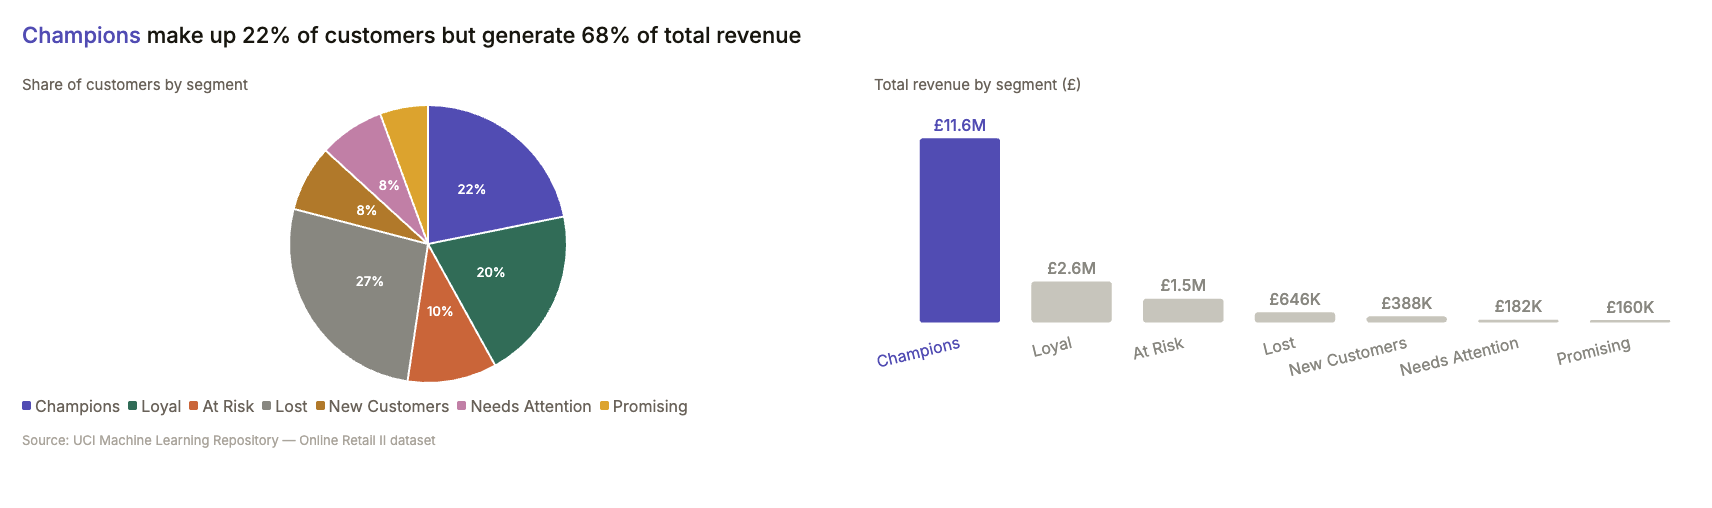

In [22]:
from IPython.display import Image
Image('../docs/img/rfm_segments.png')

## 5. Cohort Retention

In [23]:
con.execute("""
    WITH customer_month_base AS (
        SELECT
            CustomerID,
            DATE_TRUNC('month', CAST(InvoiceDate AS DATE)) AS InvoiceMonth
        FROM registered
    ),
    first_purchase_month AS (
        SELECT 
            CustomerID,
            MIN(InvoiceMonth) AS CohortMonth
        FROM customer_month_base
        GROUP BY CustomerID
    ),
    cohorts AS (
        SELECT
            cb.CustomerID,
            cb.InvoiceMonth,
            fm.CohortMonth,
            DATE_DIFF('month', fm.CohortMonth, cb.InvoiceMonth) AS CohortIndex
        FROM customer_month_base cb
        JOIN first_purchase_month fm ON cb.CustomerID = fm.CustomerID
    ),
    cohort_counts AS (
        SELECT
            CohortMonth,
            CohortIndex,
            COUNT(DISTINCT CustomerID) AS Customers
        FROM cohorts
        GROUP BY CohortMonth, CohortIndex
    ),
    cohort_size AS (
        SELECT
            CohortMonth,
            Customers AS CohortSize
        FROM cohort_counts
        WHERE CohortIndex = 0
    ),
    total_customers AS (
        SELECT SUM(CohortSize) AS TotalCohortSize
        FROM cohort_size
    )
    SELECT
        cc.CohortIndex AS Month_Since_Acquisition,
        ROUND(100.0 * SUM(cc.Customers) / MAX(tc.TotalCohortSize), 1) AS Weighted_Retention_Pct
    FROM cohort_counts cc
    CROSS JOIN total_customers tc
    GROUP BY cc.CohortIndex
    ORDER BY cc.CohortIndex
    LIMIT 13
""").fetchdf()

,Month_Since_Acquisition,Weighted_Retention_Pct
0,0,100.00
1,1,22.90
2,2,22.40
3,3,22.80
4,4,20.20
5,5,19.00
6,6,18.80
7,7,18.10
8,8,16.20
9,9,15.30


### Insights: 
#### • Big drop happens after month 0 as 77% of new customers do not return after first purchase
#### • Retention is nearly flat from month 1 to month 3

## 6. Customer Lifetime Value (CLV) Estimation
#### Estimating how much a customer is worth to the business going forward based on what they have spent already

##### Approach used:

##### • One time buyers: CLV is just what they've spent so far.
##### • Repeat buyers: I estimate what they'd spend in a year, based on their average order size and how often they buy.
##### • Customers are grouped into tiers (Low, Medium, High, Premium) based on the projected CLV, using fixed spending thresholds.

In [24]:
clv_df = con.execute("""
    WITH clv_customer_summary AS (
        SELECT
            CustomerID,
            MIN(CAST(InvoiceDate AS DATE)) AS First_Purchase,
            MAX(CAST(InvoiceDate AS DATE)) AS Last_Purchase,
            COUNT(DISTINCT Invoice) AS Total_Orders,
            SUM(Revenue) AS Total_Revenue
        FROM registered
        GROUP BY CustomerID
        HAVING SUM(Revenue) > 0
    ),
    clv_calc AS (
        SELECT
            *,
            GREATEST(DATE_DIFF('day', First_Purchase, Last_Purchase), 1) AS Lifespan_Days,
            Total_Revenue / Total_Orders AS Avg_Order_Value
        FROM clv_customer_summary
    ),
    clv_final AS (
        SELECT
            *,
            CASE WHEN Total_Orders > 1 
                 THEN Lifespan_Days::DOUBLE / (Total_Orders - 1) 
                 ELSE NULL 
            END AS Avg_Days_Between,
            CASE WHEN Total_Orders > 1 
                 THEN Avg_Order_Value * (365.0 / (Lifespan_Days::DOUBLE / (Total_Orders - 1)))
                 ELSE Total_Revenue 
            END AS Projected_CLV,
            DATE_DIFF(
                'day',
                Last_Purchase,
                (SELECT MAX(CAST(InvoiceDate AS DATE)) + INTERVAL '1 day' FROM registered)
            ) AS Days_Since_Last_Purchase
        FROM clv_calc
    )
    SELECT
        CustomerID,
        First_Purchase,
        Last_Purchase,
        Total_Orders,
        Total_Revenue,
        Avg_Order_Value,
        Lifespan_Days,
        Avg_Days_Between,
        Projected_CLV,
        Days_Since_Last_Purchase,
        (Days_Since_Last_Purchase < 180) AS Is_Active,
        CASE
            WHEN Projected_CLV <= 1000 THEN 'Low'
            WHEN Projected_CLV <= 4000 THEN 'Medium'
            WHEN Projected_CLV <= 10000 THEN 'High'
            ELSE 'Premium'
        END AS CLV_Tier
    FROM clv_final
    ORDER BY CustomerID
""").fetchdf()

clv_df.to_csv('../data/processed/clv_analysis.csv', index=False)

clv_df

,CustomerID,First_Purchase,Last_Purchase,Total_Orders,Total_Revenue,Avg_Order_Value,Lifespan_Days,Avg_Days_Between,Projected_CLV,Days_Since_Last_Purchase,Is_Active,CLV_Tier
0,"12,346.00",2009-12-14,2011-01-18,12,"77,556.46","6,463.04",400,36.36,"64,872.75",326,False,Premium
1,"12,347.00",2010-10-31,2011-12-07,8,"4,921.53",615.19,402,57.43,"3,909.98",3,True,Medium
2,"12,348.00",2010-09-27,2011-09-25,5,"1,658.40",331.68,363,90.75,"1,334.03",76,True,Medium
3,"12,349.00",2010-04-29,2011-11-21,3,"3,678.69","1,226.23",571,285.50,"1,567.68",19,True,Medium
4,"12,350.00",2011-02-02,2011-02-02,1,294.40,294.40,1,NaN,294.40,311,False,Low
...,...,...,...,...,...,...,...,...,...,...,...,...
5847,"18,283.00",2010-02-19,2011-12-06,22,"2,658.95",120.86,655,31.19,"1,414.35",4,True,Medium
5848,"18,284.00",2010-10-04,2010-10-04,1,411.68,411.68,1,NaN,411.68,432,False,Low
5849,"18,285.00",2010-02-17,2010-02-17,1,377.00,377.00,1,NaN,377.00,661,False,Low
5850,"18,286.00",2009-12-16,2010-08-20,2,"1,246.43",623.21,247,247.00,920.95,477,False,Low


### Possible Issue with Approach: Could mistake a quick burst of orders for a fast ongoing buying habit

In [27]:
con.execute("""
    SELECT
        CLV_Tier,
        COUNT(*) AS customers,
        ROUND(MEDIAN(Avg_Days_Between), 1) AS typical_gap_days,
        ROUND(MIN(Avg_Days_Between), 1) AS smallest_gap,
        ROUND(MEDIAN(365.0 / Avg_Days_Between), 1) AS implied_orders_per_year,
        MAX(ROUND(365.0 / Avg_Days_Between, 0)) AS worst_case_orders_per_year,
        ROUND(MEDIAN(Projected_CLV / Total_Revenue), 1) AS typical_multiplier,
        ROUND(MAX(Projected_CLV / Total_Revenue), 1) AS worst_multiplier
    FROM clv_df
    WHERE Total_Orders > 1
    GROUP BY CLV_Tier
    ORDER BY implied_orders_per_year DESC
""").fetchdf()

,CLV_Tier,customers,typical_gap_days,smallest_gap,implied_orders_per_year,worst_case_orders_per_year,typical_multiplier,worst_multiplier
0,Premium,282,10.30,0.20,35.40,"1,825.00",4.50,304.20
1,High,556,27.20,1.00,13.40,365.00,0.90,182.50
2,Medium,1886,61.50,4.40,5.90,82.00,0.70,36.50
3,Low,1510,153.00,21.00,2.40,17.00,0.60,8.70


#### INSIGHT: Typical_gap_days descends down almost perfectly from 7.3 premium, 25.1 high, 59.7 medium and 147.5 low. This means tier membership is decided by purchase timing rather than spend. Typical_multiplier shows the consequence with the median premium customer projected at 8.7× their lifetime spend while medium and low sit below 1×.

### Possible Issue with Approach: If a customer's first order was three week before data ends

In [52]:
con.execute("""
    SELECT
        CLV_Tier,
        COUNT(*) AS customers,
        ROUND(MEDIAN(Lifespan_Days), 0) AS typical_days_observed,
        SUM(CASE WHEN Lifespan_Days <= 30 THEN 1 ELSE 0 END) AS seen_under_a_month,
        ROUND(100.0 * SUM(CASE WHEN Lifespan_Days <= 30 THEN Projected_CLV ELSE 0 END)/ SUM(Projected_CLV), 1) AS pct_of_value_from_them
    FROM 
        clv_df
    WHERE 
        Total_Orders > 1
    GROUP BY 
        CLV_Tier
    ORDER BY 
        typical_days_observed
""").fetchdf()

,CLV_Tier,customers,typical_days_observed,seen_under_a_month,pct_of_value_from_them
0,Premium,203,25.00,103.00,79.00
1,High,528,289.00,82.00,17.20
2,Low,1601,380.00,3.00,0.30
3,Medium,1844,407.00,53.00,3.50


### INSIGHT: 
#### • Premium tier is made up of the customers with shortest days observed while low tier has one of the longest days observed. 
#### • Half of premier is made up of customer seen for under a month and those 103 cusotomers maker up 79% of the premier tier's projected value

In [57]:
clv_v2_df = con.execute("""
    WITH clv_customer_summary AS (
        SELECT
            CustomerID,
            MIN(CAST(InvoiceDate AS DATE)) AS First_Purchase,
            MAX(CAST(InvoiceDate AS DATE)) AS Last_Purchase,
            COUNT(DISTINCT Invoice) AS Total_Invoices,
            COUNT(DISTINCT CAST(InvoiceDate AS DATE)) AS Purchase_Days,
            SUM(Revenue) AS Total_Revenue
        FROM registered
        GROUP BY CustomerID
        HAVING SUM(Revenue) > 0
    ),
    clv_calc AS (
        SELECT
            *,
            DATE_DIFF('day', First_Purchase, Last_Purchase) AS Lifespan_Days,
            Total_Revenue / Purchase_Days AS Avg_Order_Value
        FROM clv_customer_summary
    ),
    clv_rates AS (
        SELECT
            *,
            CASE WHEN Purchase_Days > 1
                 THEN Lifespan_Days::DOUBLE / (Purchase_Days - 1)
                 ELSE NULL
            END AS Avg_Days_Between,
            DATE_DIFF(
                'day',
                Last_Purchase,
                (SELECT MAX(CAST(InvoiceDate AS DATE)) + INTERVAL '1 day' FROM registered)
            ) AS Days_Since_Last_Purchase
        FROM clv_calc
    ),
    clv_final AS (
        SELECT
            *,
            GREATEST(Avg_Days_Between, 14) AS Safe_Gap,
            LEAST(365.0 / GREATEST(Avg_Days_Between, 14), 26) AS Orders_Per_Year,
            (Purchase_Days > 1 AND Lifespan_Days >= 60) AS Has_Enough_History,
            CASE WHEN Purchase_Days > 1 AND Lifespan_Days >= 60
                 THEN Avg_Order_Value * LEAST(365.0 / GREATEST(Avg_Days_Between, 14), 26)
                 ELSE 0
            END AS Expected_Next_Year
        FROM clv_rates
    )
    SELECT
        CustomerID,
        First_Purchase,
        Last_Purchase,
        Total_Invoices,
        Purchase_Days,
        Total_Revenue,
        Avg_Order_Value,
        Lifespan_Days,
        Avg_Days_Between,
        Safe_Gap,
        Orders_Per_Year,
        Days_Since_Last_Purchase,
        (Days_Since_Last_Purchase < 180) AS Is_Active,
        Has_Enough_History,
        Total_Revenue AS Already_Spent,
        Expected_Next_Year,
        Total_Revenue + Expected_Next_Year AS Total_CLV,
        CASE
            WHEN Total_Revenue + Expected_Next_Year <= 1000 THEN 'Low'
            WHEN Total_Revenue + Expected_Next_Year <= 4000 THEN 'Medium'
            WHEN Total_Revenue + Expected_Next_Year <= 10000 THEN 'High'
            ELSE 'Premium'
        END AS CLV_Tier
    FROM clv_final
    ORDER BY CustomerID
""").fetchdf()
clv_v2_df

,CustomerID,First_Purchase,Last_Purchase,Total_Invoices,Purchase_Days,Total_Revenue,Avg_Order_Value,Lifespan_Days,Avg_Days_Between,Safe_Gap,Orders_Per_Year,Days_Since_Last_Purchase,Is_Active,Has_Enough_History,Already_Spent,Expected_Next_Year,Total_CLV,CLV_Tier
0,"12,346.00",2009-12-14,2010-06-28,11,7,372.86,53.27,196,32.67,32.67,11.17,530,False,True,372.86,595.16,968.02,Low
1,"12,347.00",2010-10-31,2011-12-07,8,8,"4,671.93",583.99,402,57.43,57.43,6.36,3,True,True,"4,671.93","3,711.69","8,383.62",High
2,"12,348.00",2010-09-27,2011-09-25,5,5,"1,057.24",211.45,363,90.75,90.75,4.02,76,True,True,"1,057.24",850.45,"1,907.69",Medium
3,"12,349.00",2010-04-29,2011-11-21,3,3,"3,498.94","1,166.31",571,285.50,285.50,1.28,19,True,True,"3,498.94","1,491.08","4,990.02",High
4,"12,350.00",2011-02-02,2011-02-02,1,1,294.40,294.40,0,NaN,14.00,26.00,311,False,False,294.40,0.00,294.40,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5775,"18,283.00",2010-02-19,2011-12-06,22,19,"2,664.90",140.26,655,36.39,36.39,10.03,4,True,True,"2,664.90","1,406.86","4,071.76",High
5776,"18,284.00",2010-10-04,2010-10-04,1,1,411.68,411.68,0,NaN,14.00,26.00,432,False,False,411.68,0.00,411.68,Low
5777,"18,285.00",2010-02-17,2010-02-17,1,1,173.00,173.00,0,NaN,14.00,26.00,661,False,False,173.00,0.00,173.00,Low
5778,"18,286.00",2009-12-16,2010-08-20,2,2,"1,171.58",585.79,247,247.00,247.00,1.48,477,False,True,"1,171.58",865.64,"2,037.22",Medium


In [60]:
con.execute("""
    SELECT
        CLV_Tier,
        COUNT(*)                                        AS customers,
        ROUND(MEDIAN(Avg_Days_Between), 1)              AS typical_gap_days,
        ROUND(MIN(Avg_Days_Between), 1)                 AS smallest_gap,
        ROUND(MEDIAN(365.0 / Avg_Days_Between), 1)      AS raw_orders_per_year,
        MAX(ROUND(365.0 / Avg_Days_Between, 0))         AS worst_raw_orders_per_year,
        ROUND(MEDIAN(Orders_Per_Year), 1)               AS capped_orders_per_year,
        ROUND(MAX(Orders_Per_Year), 1)                  AS worst_capped_orders_per_year,
        ROUND(MEDIAN(Total_CLV / Total_Revenue), 1)     AS typical_multiplier,
        ROUND(MAX(Total_CLV / Total_Revenue), 1)        AS worst_multiplier
    FROM clv_v2_df
    WHERE Purchase_Days > 1
    GROUP BY CLV_Tier
    ORDER BY capped_orders_per_year DESC
""").fetchdf()

,CLV_Tier,customers,typical_gap_days,smallest_gap,raw_orders_per_year,worst_raw_orders_per_year,capped_orders_per_year,worst_capped_orders_per_year,typical_multiplier,worst_multiplier
0,Premium,430,31.20,3.00,11.70,121.00,11.70,26.00,1.50,5.30
1,High,945,59.50,1.00,6.10,365.00,6.10,26.00,1.60,5.80
2,Medium,1871,102.30,1.00,3.60,365.00,3.60,26.00,1.70,5.50
3,Low,879,134.00,1.00,2.70,365.00,2.70,26.00,1.50,4.30


### The first issues identified found that tiers were defined by purchase timing over spend and 

In [18]:
# Active vs churned counts
active_count = clv_df['Is_Active'].sum()
churned_count = (~clv_df['Is_Active']).sum()

print(f"Active customers  : {active_count:,}")
print(f"Churned customers : {churned_count:,}")

Active customers  : 3,420
Churned customers : 2,360


In [19]:
con.execute("""
    SELECT
        CLV_Tier,
        ROUND(100.0 * COUNT(CustomerID) / SUM(COUNT(CustomerID)) OVER (), 1) AS "Pct of Customers",
        SUM(Projected_CLV) AS "Total Projected CLV",
        ROUND(100.0 * SUM(Projected_CLV) / SUM(SUM(Projected_CLV)) OVER (), 1) AS "Pct of Projected CLV",
    FROM
        clv_df
    GROUP BY
        CLV_Tier
    ORDER BY
        AVG(Projected_CLV) DESC
""").fetchdf()

,CLV_Tier,Pct of Customers,Total Projected CLV,Pct of Projected CLV
0,Premium,3.50,"10,262,202.61",55.20
1,High,9.20,"3,196,405.09",17.20
2,Medium,32.80,"3,862,911.93",20.80
3,Low,54.50,"1,259,430.22",6.80


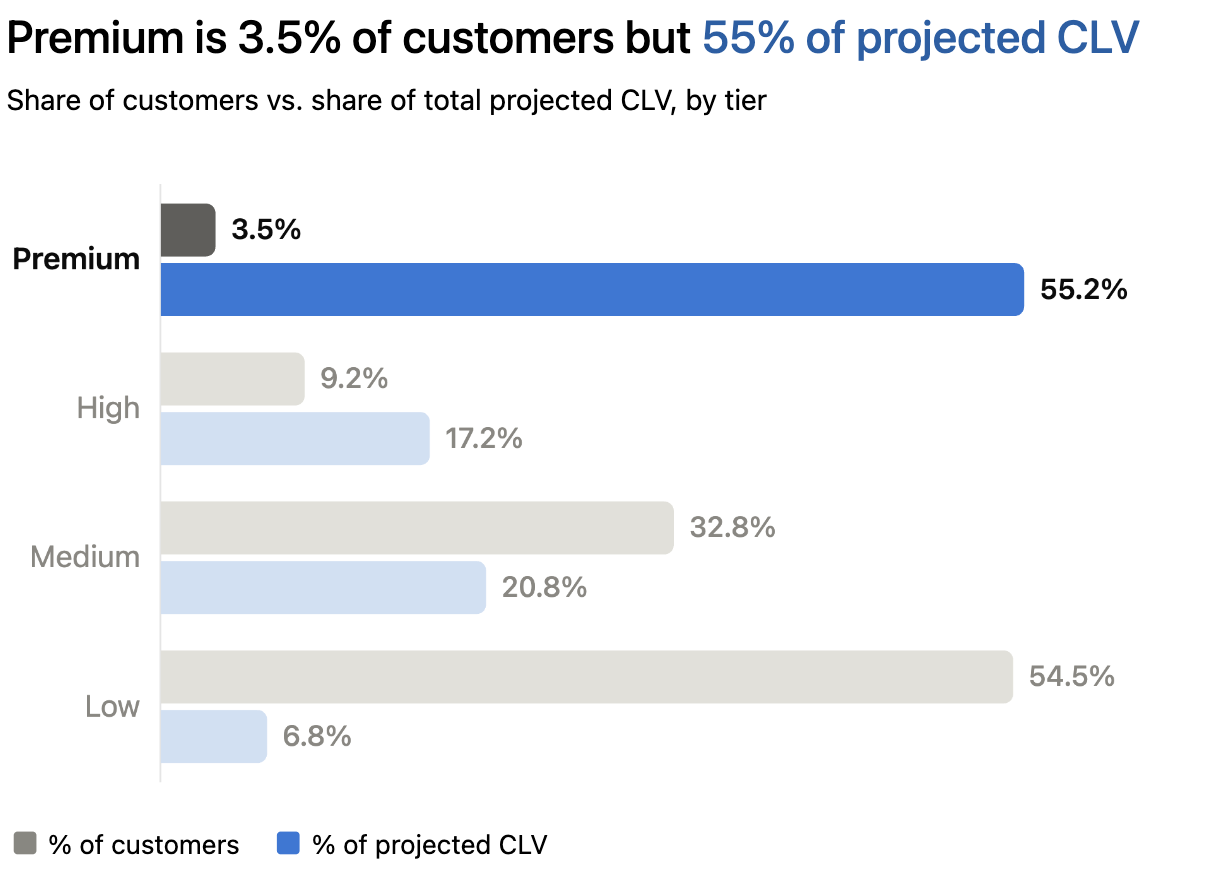

In [20]:
from IPython.display import Image
Image('../docs/img/clv_tier_analysis.png')

## 7. RFM Segments vs CLV

In [21]:
rfm_clv_df = con.execute("""
    SELECT
        clv_df.*,
        rfm_segments.Recency,
        rfm_segments.Frequency,
        rfm_segments.Monetary,
        rfm_segments.R_Score,
        rfm_segments.F_Score,
        rfm_segments.M_Score,
        rfm_segments.RFM_Score,
        rfm_segments.Segment
    FROM clv_df
    JOIN rfm_segments ON clv_df.CustomerID = rfm_segments.CustomerID
    ORDER BY clv_df.CustomerID
""").fetchdf()

rfm_clv_df

,CustomerID,First_Purchase,Last_Purchase,Total_Orders,Total_Revenue,Avg_Order_Value,Lifespan_Days,Avg_Days_Between,Projected_CLV,Days_Since_Last_Purchase,Is_Active,CLV_Tier,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,"12,346.00",2009-12-14,2010-06-28,11,372.86,33.90,196,19.60,631.23,530,False,Low,530,11,372.86,1,5,2,152,Needs Attention
1,"12,347.00",2010-10-31,2011-12-07,8,"4,671.93",583.99,402,57.43,"3,711.69",3,True,Medium,3,8,"4,671.93",5,5,5,555,Champions
2,"12,348.00",2010-09-27,2011-09-25,5,"1,057.24",211.45,363,90.75,850.45,76,True,Low,76,5,"1,057.24",3,4,3,343,Loyal
3,"12,349.00",2010-04-29,2011-11-21,3,"3,498.94","1,166.31",571,285.50,"1,491.08",19,True,Medium,19,3,"3,498.94",5,3,5,535,Loyal
4,"12,350.00",2011-02-02,2011-02-02,1,294.40,294.40,1,NaN,294.40,311,False,Low,311,1,294.40,2,1,2,212,Lost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5775,"18,283.00",2010-02-19,2011-12-06,22,"2,664.90",121.13,655,31.19,"1,417.52",4,True,Medium,4,22,"2,664.90",5,5,5,555,Champions
5776,"18,284.00",2010-10-04,2010-10-04,1,411.68,411.68,1,NaN,411.68,432,False,Low,432,1,411.68,1,2,2,122,Lost
5777,"18,285.00",2010-02-17,2010-02-17,1,173.00,173.00,1,NaN,173.00,661,False,Low,661,1,173.00,1,1,1,111,Lost
5778,"18,286.00",2009-12-16,2010-08-20,2,"1,171.58",585.79,247,247.00,865.64,477,False,Low,477,2,"1,171.58",1,2,4,124,Lost


In [22]:
rfm_clv_analysis = con.execute("""
    WITH segments_clv AS (
        SELECT
            Segment,
            Count(CustomerID) AS customer_count,
            AVG(Projected_CLV) AS average_clv,
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY Projected_CLV) AS median_clv,
            SUM(Projected_CLV) AS total_clv
        FROM 
            rfm_clv_df
        GROUP BY
            Segment
    )
    SELECT 
        *,
        ROUND(100 * customer_count / SUM(customer_count) OVER (), 2) AS customer_share_pct,
        ROUND(100 *  total_clv / SUM(total_clv) OVER (), 2) AS clv_share_pct
    FROM
        segments_clv
    ORDER BY
        clv_share_pct DESC
""").fetchdf()

rfm_clv_analysis

,Segment,customer_count,average_clv,median_clv,total_clv,customer_share_pct,clv_share_pct
0,Champions,1291,"5,774.99","2,413.91","7,455,505.82",22.34,40.12
1,Lost,1568,"2,787.14",289.59,"4,370,237.12",27.13,23.52
2,Loyal,1141,"2,126.37","1,063.21","2,426,186.50",19.74,13.06
3,At Risk,592,"3,188.85","1,439.71","1,887,801.48",10.24,10.16
4,Promising,418,"2,685.37",336.17,"1,122,485.70",7.23,6.04
5,Needs Attention,444,"2,281.37",388.15,"1,012,930.19",7.68,5.45
6,New Customers,326,938.05,279.74,"305,803.04",5.64,1.65


## 8. Geographic Analysis

In [23]:
# Top 10 Countries By Revenue

top_country_revenue = con.execute("""
    WITH country_stats AS (
        SELECT 
            Country,
            Sum(Revenue) as Revenue,
            COUNT(DISTINCT CustomerID) as Customers,
            COUNT(DISTINCT Invoice) as Orders
        FROM
            cleaned
        GROUP BY
            Country
        ORDER BY
            Sum(Revenue) DESC
        LIMIT 10
    )
    SELECT 
        *,
        (Revenue / (SELECT SUM(Revenue) FROM cleaned))*100 as "Market Share %",
        Orders/Customers as Order_Per_Customer
    FROM
        country_stats
""").fetchdf()

top_country_revenue

,Country,Revenue,Customers,Orders,Market Share %,Order_Per_Customer
0,United Kingdom,"12,656,167.76",5265,35037,86.53,6.65
1,EIRE,"398,572.95",3,568,2.73,189.33
2,Germany,"378,200.77",107,767,2.59,7.17
3,France,"291,565.69",93,605,1.99,6.51
4,Netherlands,"217,094.54",22,208,1.48,9.45
5,Switzerland,"84,253.72",22,86,0.58,3.91
6,Spain,"63,685.10",37,136,0.44,3.68
7,Belgium,"61,904.94",29,145,0.42,5.00
8,Australia,"60,556.48",15,84,0.41,5.60
9,Portugal,"45,747.92",23,84,0.31,3.65


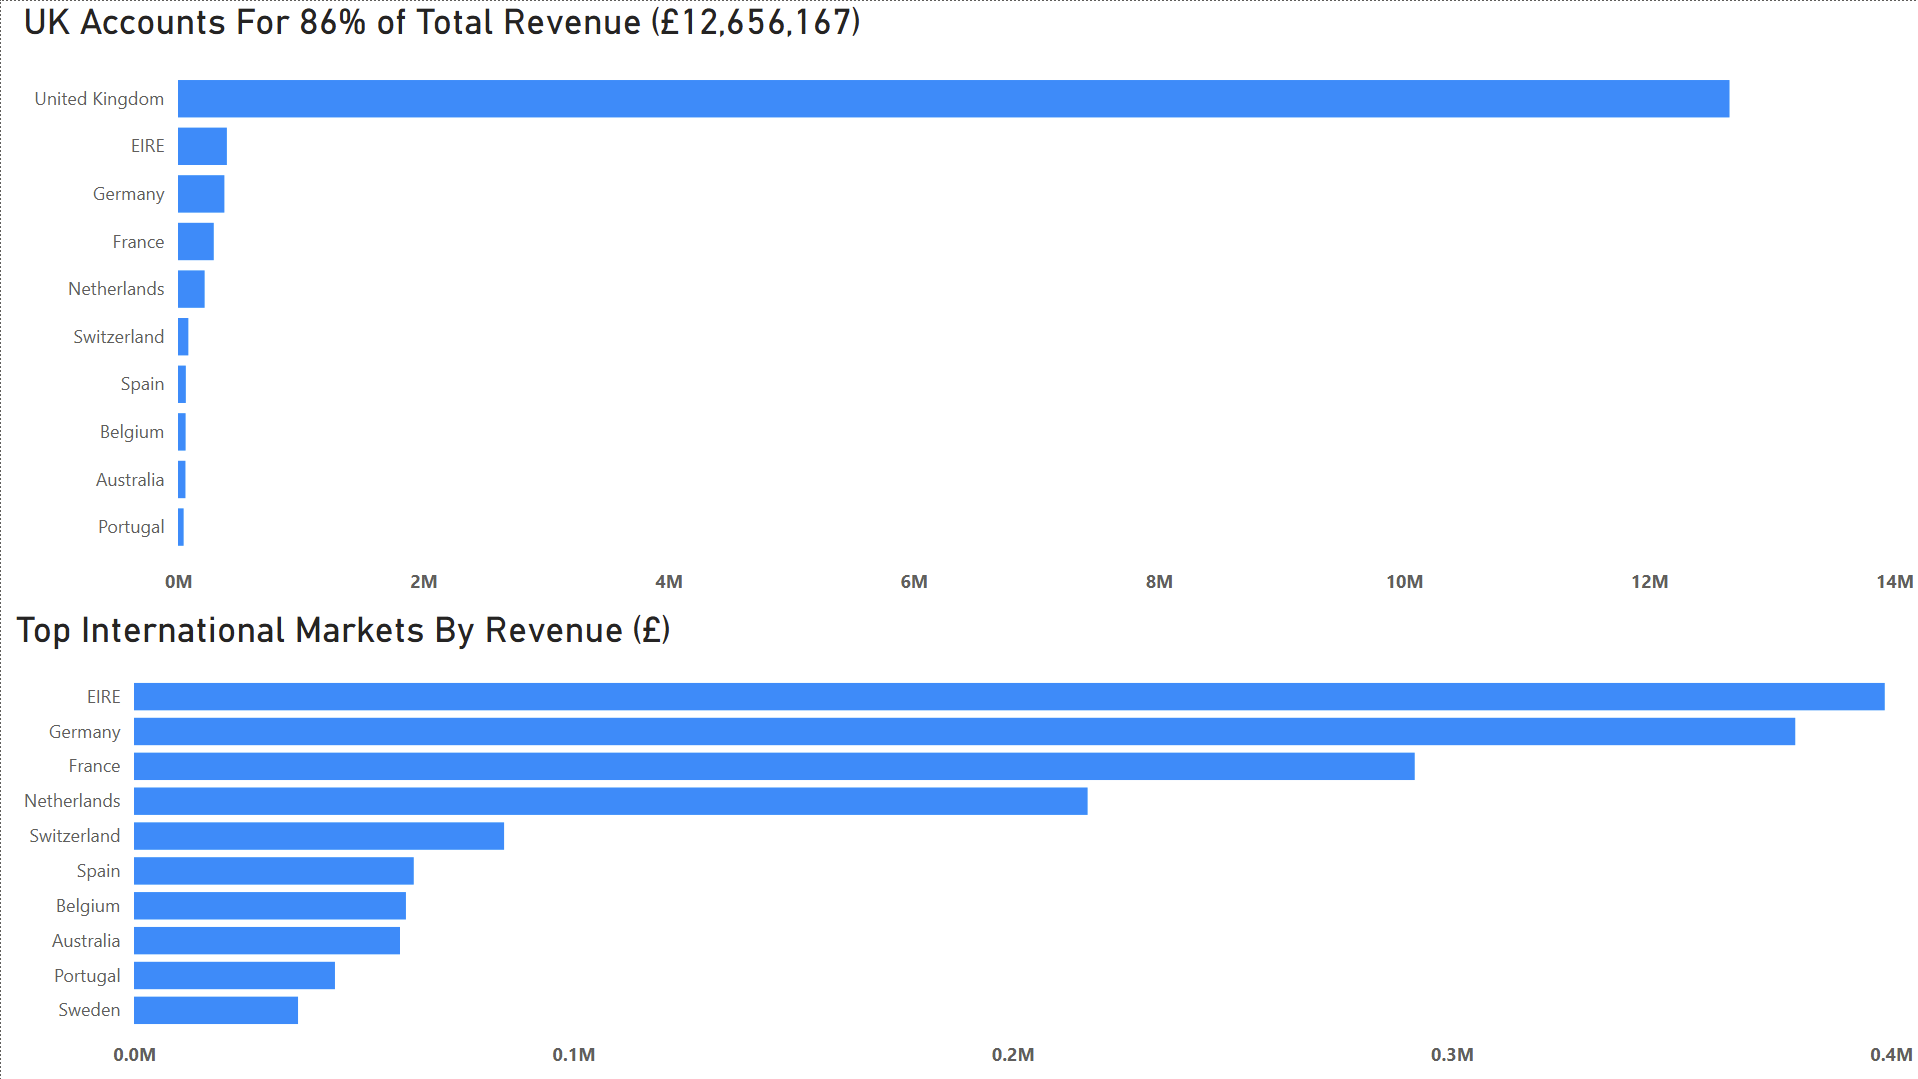

In [24]:
from IPython.display import Image
Image('../docs/img/total_revenue_country.png', width=1000, height=600)

In [25]:
# Customer Orders and Revenue in EIRE
con.execute("""
    SELECT 
        CustomerID,
        COUNT(DISTINCT Invoice) as Orders,
        SUM(Revenue) as Revenue
    FROM cleaned
    WHERE Country = 'EIRE'
    GROUP BY CustomerID
    ORDER BY SUM(Revenue) DESC
""").fetchdf()

,CustomerID,Orders,Revenue
0,"14,911.00",373,"245,187.45"
1,"14,156.00",131,"106,671.21"
2,NaN,53,"35,916.43"
3,"14,016.00",11,"10,797.86"


In [26]:
# Customer Orders and Revenue in Germany
con.execute("""
    SELECT 
        CustomerID,
        COUNT(DISTINCT Invoice) as Orders,
        SUM(Revenue) as Revenue
    FROM cleaned
    WHERE Country = 'Germany'
    GROUP BY CustomerID
    ORDER BY SUM(Revenue) DESC
""").fetchdf()

,CustomerID,Orders,Revenue
0,"12,471.00",72,"32,530.30"
1,"12,709.00",32,"22,148.06"
2,"12,621.00",35,"20,466.52"
3,"12,477.00",9,"18,241.57"
4,"12,472.00",19,"16,219.34"
...,...,...,...
102,"12,622.00",1,180.10
103,"12,738.00",1,155.35
104,"12,603.00",1,126.00
105,"12,652.00",1,97.05


In [27]:
# Customer Orders and Revenue in France
con.execute("""
    SELECT 
        CustomerID,
        COUNT(DISTINCT Invoice) as Orders,
        SUM(Revenue) as Revenue
    FROM cleaned
    WHERE Country = 'France'
    GROUP BY CustomerID
    ORDER BY SUM(Revenue) DESC
""").fetchdf()

,CustomerID,Orders,Revenue
0,"12,681.00",45,"29,574.36"
1,"12,682.00",52,"22,348.78"
2,"12,678.00",15,"19,734.26"
3,"12,731.00",17,"18,511.25"
4,"12,714.00",12,"14,093.71"
...,...,...,...
89,"12,602.00",1,153.12
90,"12,692.00",1,110.95
91,"12,659.00",1,91.68
92,"12,686.00",1,89.14


In [28]:
# Customer Orders and Revenue in Netherlands
con.execute("""
    SELECT 
        CustomerID,
        COUNT(DISTINCT Invoice) as Orders,
        SUM(Revenue) as Revenue
    FROM cleaned
    WHERE Country = 'Netherlands'
    GROUP BY CustomerID
    ORDER BY SUM(Revenue) DESC
""").fetchdf()

,CustomerID,Orders,Revenue
0,"14,646.00",134,"193,095.27"
1,"12,759.00",8,"5,020.74"
2,"12,802.00",7,"2,287.94"
3,"12,806.00",3,"2,039.72"
4,"12,778.00",9,"1,775.68"
5,"12,775.00",7,"1,686.12"
6,"12,813.00",3,"1,435.80"
7,"12,805.00",4,"1,434.95"
8,"12,765.00",6,"1,404.58"
9,"12,803.00",1,"1,092.81"


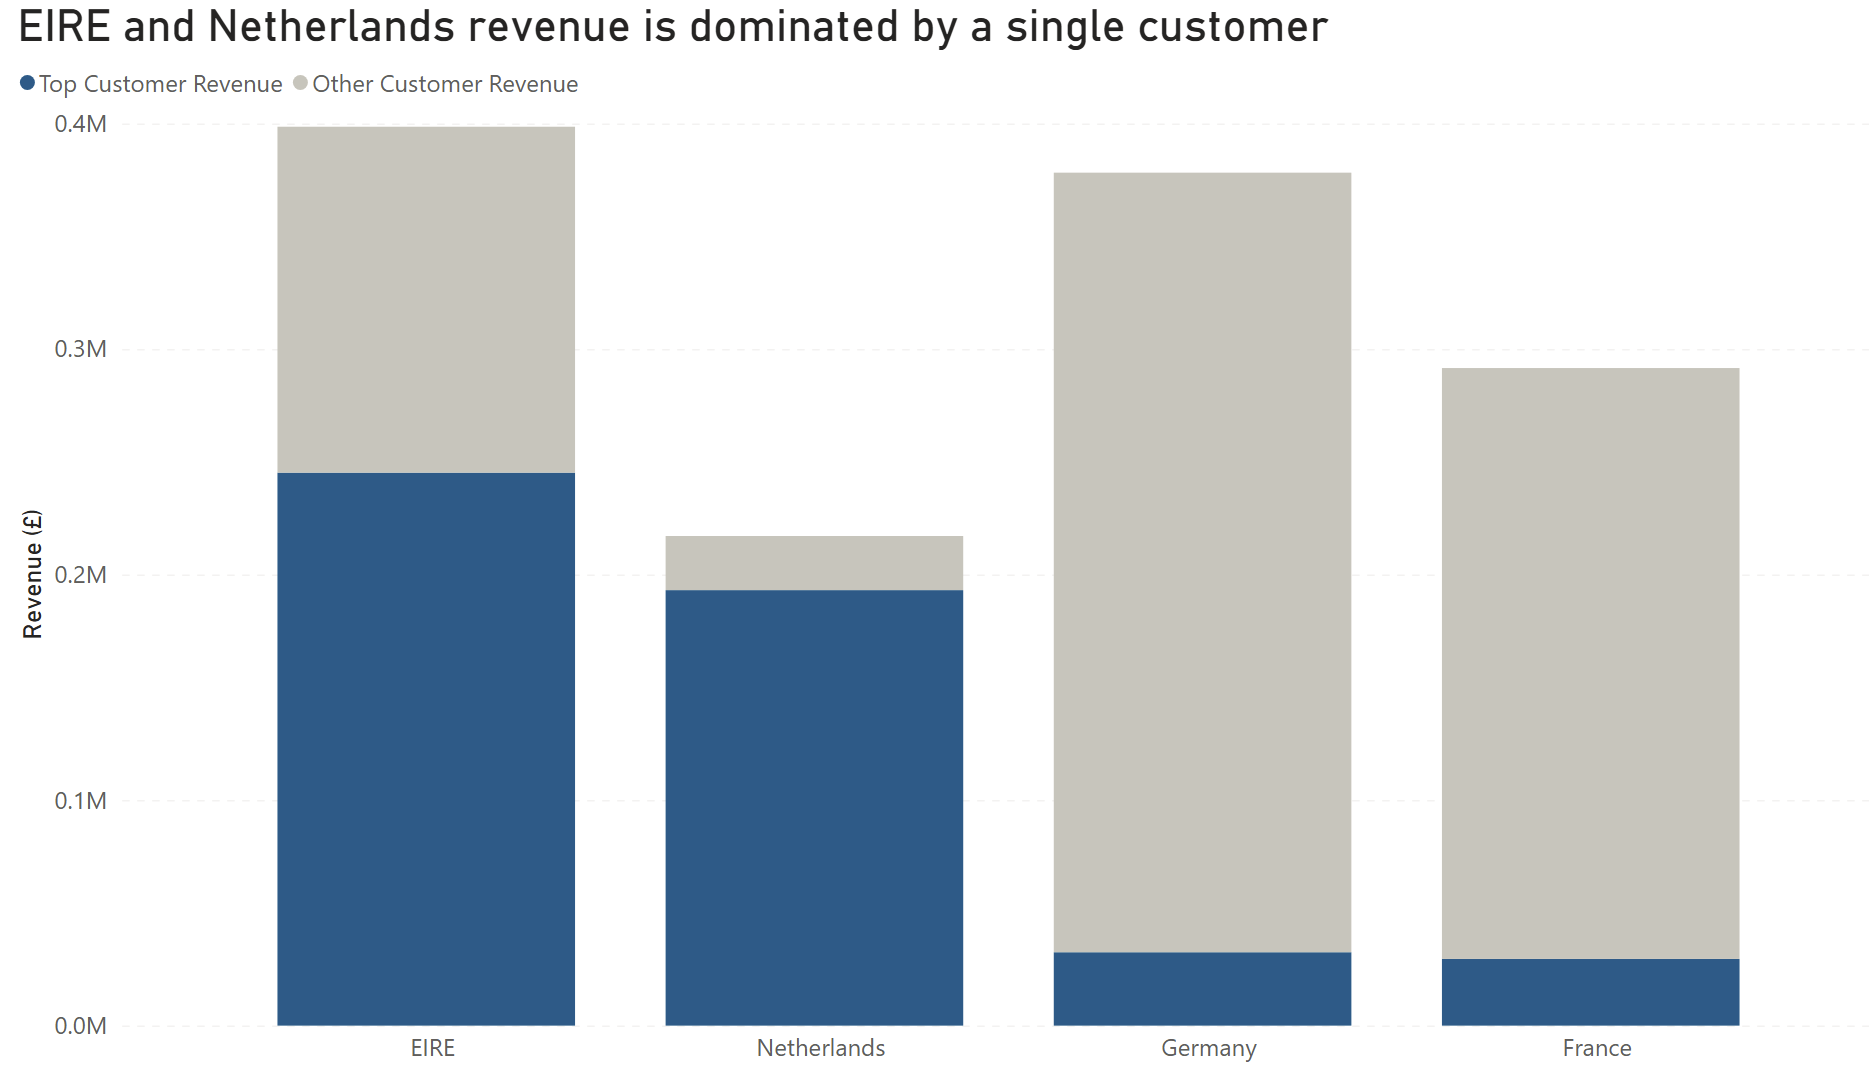

In [29]:
Image('../docs/img/revenue_by_country.png', width=1000, height=600)

#### • EIRE generates the highest revenue by a non UK country but there are only 3 customers from that country suggesting wholesale/trade buyers placing enormous repeat orders.
#### • Netherlands has more unique customers than ireland but vast majority of orders being made by 1 customer

## 9. Product Analysis

In [30]:
# Top 10 Products By Revenue

con.execute("""
    SELECT 
        StockCode,
        Description,
        Sum(Revenue) as Revenue,
        Sum(Quantity) as Quantity,
        COUNT(DISTINCT Invoice) as Orders
    FROM
        cleaned
    GROUP BY
        StockCode,
        Description
    ORDER BY
        Sum(Revenue) DESC
    LIMIT 10
""").fetchdf()

,StockCode,Description,Revenue,Quantity,Orders
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"172,201.54","61,860.00",5227
1,22423,REGENCY CAKESTAND 3 TIER,"171,361.78","14,407.00",3213
2,85099B,JUMBO BAG RED RETROSPOT,"100,338.57","51,436.00",3143
3,84879,ASSORTED COLOUR BIRD ORNAMENT,"75,321.42","43,926.00",2642
4,47566,PARTY BUNTING,"74,361.47","13,659.00",2453
5,POST,POSTAGE,"68,350.24","4,009.00",1417
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"59,055.46","18,643.00",1910
7,21931,JUMBO STORAGE BAG SUKI,"55,393.90","26,856.00",2313
8,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,"50,291.45","23,935.00",2173
9,85099F,JUMBO BAG STRAWBERRY,"47,819.22","25,275.00",1786


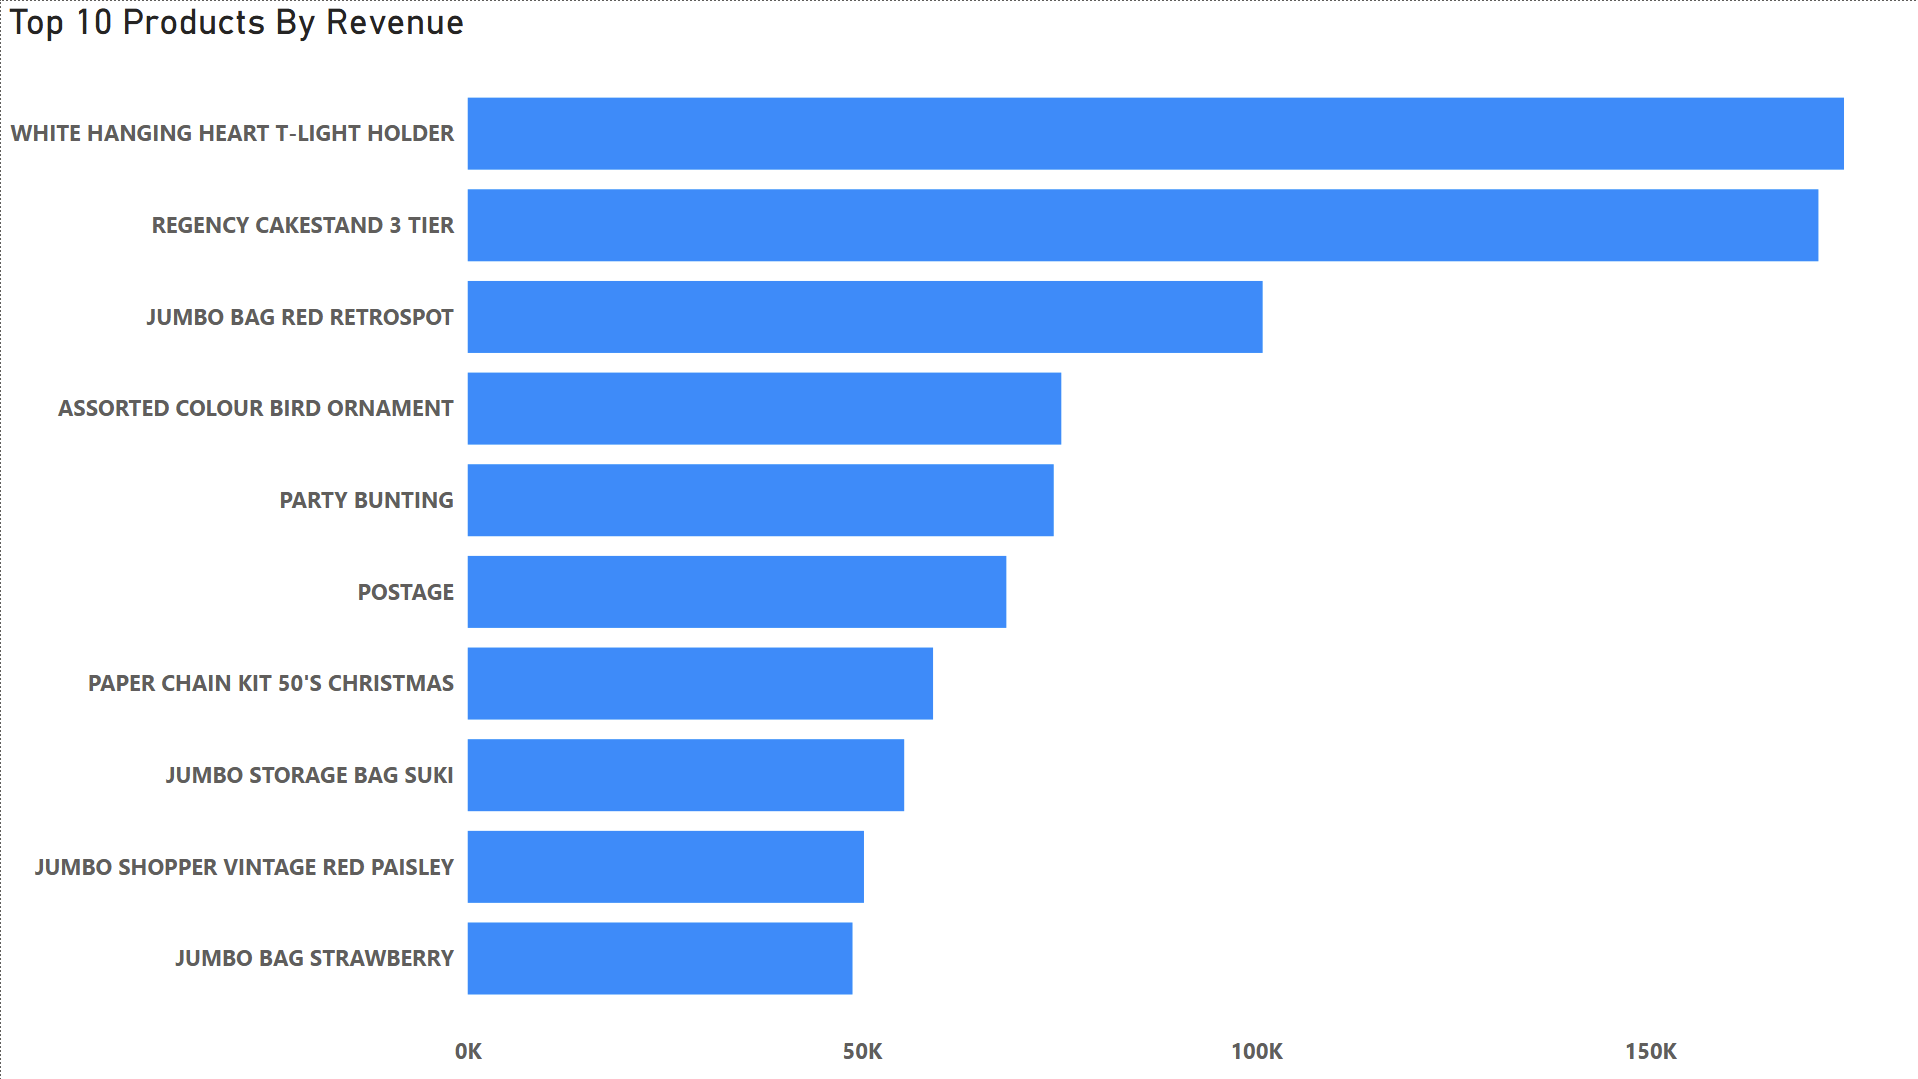

In [31]:
from IPython.display import Image
Image('../docs/img/total_revenue_product.png', width=1000, height=600)

## 10. Time Patterns

In [32]:
# Revenue By Day of Week
revenue_day = con.execute("""
    WITH day_of_week AS (
        SELECT
            *,
            CASE
                WHEN DayOfWeek = 0 Then 'Sunday'
                WHEN DayOfWeek = 1 Then 'Monday'
                WHEN DayOfWeek = 2 Then 'Tuesday'
                WHEN DayOfWeek = 3 Then 'Wednesday'
                WHEN DayOfWeek = 4 Then 'Thursday'
                WHEN DayOfWeek = 5 Then 'Friday'
                ELSE 'Saturday'
            END AS Days
        FROM
            cleaned
    )
    SELECT
        Days,
        Sum(Revenue) as Revenue
    FROM 
        day_of_week
    GROUP BY
        Days
    ORDER BY
        Revenue DESC
""").fetchdf()

revenue_day

,Days,Revenue
0,Thursday,"2,932,791.40"
1,Tuesday,"2,792,959.77"
2,Wednesday,"2,640,114.06"
3,Monday,"2,442,121.66"
4,Friday,"2,224,257.61"
5,Sunday,"1,584,195.74"
6,Saturday,"9,488.27"


In [33]:
IFrame('../docs/img/revenue_by_day.html', width=900, height=520)

In [34]:
# Revenue By Hour

revenue_hour = con.execute("""
    SELECT
        Hour,
        Sum(Revenue) as Revenue
    FROM 
        cleaned
    GROUP BY
        Hour
    ORDER BY
        Revenue DESC
""").fetchdf()

revenue_hour

,Hour,Revenue
0,12,"2,163,107.26"
1,13,"2,005,914.35"
2,14,"1,842,055.00"
3,10,"1,737,483.93"
4,11,"1,731,064.50"
5,15,"1,689,547.14"
6,9,"1,165,686.89"
7,16,"1,003,737.88"
8,17,"580,720.69"
9,8,"375,590.03"


In [35]:
IFrame('../docs/img/revenue_by_hour.html', width=900, height=520)

## 11. Key Findings Summary

In [36]:
print('=' * 60)
print('📊 KEY FINDINGS SUMMARY')
print('=' * 60)

uk_revenue = top_country_revenue.loc[top_country_revenue['Country'] == 'United Kingdom', 'Revenue'].values[0]
uk_share = (uk_revenue/totals['total_revenue'][0])*100

peak_day = revenue_day['Days'].iloc[0]
peak_hour = revenue_hour['Hour'].iloc[0]


print(f"""
1. REVENUE OVERVIEW
   • Total Revenue: £{totals['total_revenue'][0]:,.2f}
   • Total Orders: {totals['total_orders'][0]:,}
   • Average Order Value: £{totals['total_revenue'][0]/totals['total_orders'][0]:.2f}
   
2. SEASONALITY
   • November generates the highest average monthly revenue (holiday shopping)
   • Recommendation: Increase inventory by 40% in October

3. CUSTOMER SEGMENTS
   • Total Customers: {totals['total_customers'][0]:,}
   • {top_seg} generate {top_rev_pct}% of total revenue
   • Recommendation: Create VIP loyalty program for {top_seg}

4. GEOGRAPHIC INSIGHTS
   • UK: {uk_share:.0f}% of revenue
   • Top international: EIRE, Germany, France, Netherlands. Bulk of revenue in EIRE and Netherlands driven by 1 customer
   • Recommendation: Invest in EU marketing and fulfillment for Germany and France

5. TIMING PATTERNS
   • Peak day: {peak_day}
   • Peak hour: {int(peak_hour)}:00
   • Recommendation: Schedule campaigns around peak times

""")

📊 KEY FINDINGS SUMMARY

1. REVENUE OVERVIEW
   • Total Revenue: £14,625,928.52
   • Total Orders: 38,339
   • Average Order Value: £381.49

2. SEASONALITY
   • November generates the highest average monthly revenue (holiday shopping)
   • Recommendation: Increase inventory by 40% in October

3. CUSTOMER SEGMENTS
   • Total Customers: 5,780
   • Champions generate 66% of total revenue
   • Recommendation: Create VIP loyalty program for Champions

4. GEOGRAPHIC INSIGHTS
   • UK: 87% of revenue
   • Top international: EIRE, Germany, France, Netherlands. Bulk of revenue in EIRE and Netherlands driven by 1 customer
   • Recommendation: Invest in EU marketing and fulfillment for Germany and France

5. TIMING PATTERNS
   • Peak day: Thursday
   • Peak hour: 12:00
   • Recommendation: Schedule campaigns around peak times


